# Eksplorasi Data - Kabupaten Bangkalan

Eksplorasi Data adalah tahap untuk melihat, memvisualisasikan, dan
memeriksa kualitas data yang telah diperoleh pada tahap Data
Understanding, sebelum data diolah lebih lanjut pada tahap analisis
utama. Bagian ini mencakup peta interaktif wilayah, statistik deskriptif,
pemeriksaan missing values, dan deteksi outlier awal, menggunakan satu
tabel gabungan hasil ekstraksi.

## 1. Peta Interaktif Wilayah Bangkalan

Peta berikut menampilkan **batas administratif asli Kabupaten Bangkalan**
menggunakan `folium.GeoJson`, bukan kotak bounding box, beserta titik
pusat wilayah dan beberapa titik acuan kontekstual, yaitu akses Suramadu
dan area pesisir Klampis, yang relevan sebagai potensi sumber emisi. Peta
mendukung dua basemap, yaitu peta jalan dan citra satelit, yang dapat
dipilih melalui kontrol layer di kanan atas peta.

Bentuk polygon yang ditampilkan sama persis dengan polygon yang dipakai
pada `aggregate_spatial` di notebook ekstraksi, sehingga peta ini juga
berfungsi memverifikasi area yang sesungguhnya diagregasi, bukan sekadar
ilustrasi.

In [1]:
import json

import folium
from folium.plugins import Fullscreen, MeasureControl, MiniMap

with open("../data/bangkalan-boundary.geojson", encoding="utf-8") as f:
    bangkalan_geojson = json.load(f)

coords = bangkalan_geojson["geometry"]["coordinates"][0]
centroid_lon = sum(pt[0] for pt in coords) / len(coords)
centroid_lat = sum(pt[1] for pt in coords) / len(coords)

landmarks = [
    {"name": "Pusat Kota Bangkalan", "lat": -7.0392, "lon": 112.7487,
     "desc": "Pusat pemerintahan Kabupaten Bangkalan."},
    {"name": "Jembatan Suramadu (sisi Madura)", "lat": -7.1743, "lon": 112.7614,
     "desc": "Titik masuk arus kendaraan dari Surabaya, sumber emisi transportasi."},
    {"name": "Kecamatan Klampis (pesisir utara)", "lat": -6.9028, "lon": 112.9764,
     "desc": "Area pesisir dengan rencana fasilitas stockpile batu bara."},
]

m = folium.Map(location=(centroid_lat, centroid_lon), zoom_start=10, tiles=None, control_scale=True)
folium.TileLayer("OpenStreetMap", name="Peta Jalan").add_to(m)
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri, Maxar, Earthstar Geographics",
    name="Citra Satelit",
).add_to(m)

folium.GeoJson(
    bangkalan_geojson,
    name="Batas Kabupaten Bangkalan",
    style_function=lambda feature: {
        "fillColor": "#d62728", "color": "#d62728", "weight": 2.5, "fillOpacity": 0.08,
    },
    tooltip="Batas administratif Kabupaten Bangkalan",
).add_to(m)

folium.Marker(
    location=(centroid_lat, centroid_lon), tooltip="Titik pusat (centroid) Kabupaten Bangkalan",
    icon=folium.Icon(color="red", icon="cloud", prefix="fa"),
).add_to(m)

for lm in landmarks:
    folium.Marker(
        location=(lm["lat"], lm["lon"]), tooltip=lm["name"],
        popup=f"<b>{lm['name']}</b><br>{lm['desc']}",
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
MiniMap(toggle_display=True, position="bottomleft").add_to(m)
Fullscreen(position="topleft").add_to(m)
MeasureControl(primary_length_unit="kilometers").add_to(m)

m

## 2. Memuat Tabel Gabungan Hasil Ekstraksi

Data yang dimuat adalah satu tabel tunggal `bangkalan_polutan.csv`, dengan
kolom `date`, `NO2`, `CO`, `SO2`, dan `CH4`, mirip struktur tabel pada
basis data, bukan empat file terpisah.

In [2]:
import pandas as pd

pollutants = ["NO2", "CO", "SO2", "CH4"]

df = pd.read_csv("../data/csv/bangkalan_polutan.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Dimuat: {len(df)} baris, dari {df['date'].min().date()} sampai {df['date'].max().date()}")
df.head()

Dimuat: 314 baris, dari 2025-08-24 sampai 2026-08-23


,date,NO2,CO,SO2,CH4
0,2025-08-24,0.0,0.0,0.0,0.0
1,2025-08-25,0.0,0.0,0.0,0.0
2,2025-08-26,0.0,NaN,0.0,NaN
3,2025-08-27,0.0,0.0,0.0,0.0
4,2025-08-28,0.0,0.0,0.0,NaN


## 3. Statistik Deskriptif

Statistik deskriptif memberikan gambaran umum sebaran nilai tiap polutan,
seperti nilai rata rata, nilai minimum, nilai maksimum, dan sebaran
kuartil. Nilai ditampilkan dalam notasi ilmiah karena konsentrasi trace
gas pada data Sentinel-5P umumnya sangat kecil, sehingga pembulatan
desimal biasa dapat menyembunyikan nilai yang sebenarnya bukan nol.

In [3]:
summary_rows = []
for pollutant in pollutants:
    desc = df[pollutant].describe()
    summary_rows.append({
        "polutan": pollutant,
        "jumlah_data": int(desc["count"]),
        "rata_rata": f"{desc['mean']:.3e}",
        "std": f"{desc['std']:.3e}",
        "minimum": f"{desc['min']:.3e}",
        "maksimum": f"{desc['max']:.3e}",
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,polutan,jumlah_data,rata_rata,std,minimum,maksimum
0,NO2,278,0.000e+00,0.000e+00,0.000e+00,0.000e+00
1,CO,270,0.000e+00,0.000e+00,0.000e+00,0.000e+00
2,SO2,298,0.000e+00,0.000e+00,0.000e+00,0.000e+00
3,CH4,71,0.000e+00,0.000e+00,0.000e+00,0.000e+00


## 4. Pemeriksaan Missing Values

Pemeriksaan dilakukan dengan melengkapi deret waktu agar memiliki baris
untuk setiap hari dalam rentang tanggal, karena sebagian hari mungkin
tidak memiliki data sama sekali, misalnya akibat tutupan awan atau tidak
adanya lintasan satelit pada hari tersebut.

In [4]:
df_full = df.set_index("date").asfreq("D")
for pollutant in pollutants:
    n_missing = df_full[pollutant].isna().sum()
    pct_missing = 100 * n_missing / len(df_full)
    print(f"{pollutant}: {n_missing} dari {len(df_full)} hari kosong ({pct_missing:.1f} persen)")

NO2: 87 dari 365 hari kosong (23.8 persen)
CO: 95 dari 365 hari kosong (26.0 persen)
SO2: 67 dari 365 hari kosong (18.4 persen)
CH4: 294 dari 365 hari kosong (80.5 persen)


Pola dan besaran missing values ini menjadi catatan penting yang akan
ditangani, misalnya dengan interpolasi berbasis waktu, sebelum data
dipakai pada notebook analisis utama.

## 5. Deteksi Outlier Awal

Deteksi outlier awal dilakukan menggunakan algoritma **Isolation Forest**
dengan `contamination=0.05`, artinya diperkirakan sekitar 5 persen dari
data adalah outlier. Baris dengan nilai kosong dibuang terlebih dahulu
(`dropna`) agar tidak mengganggu proses pemodelan.

NO2: 0 outlier dari 278 data valid


CO: 0 outlier dari 270 data valid


SO2: 0 outlier dari 298 data valid


CH4: 0 outlier dari 71 data valid


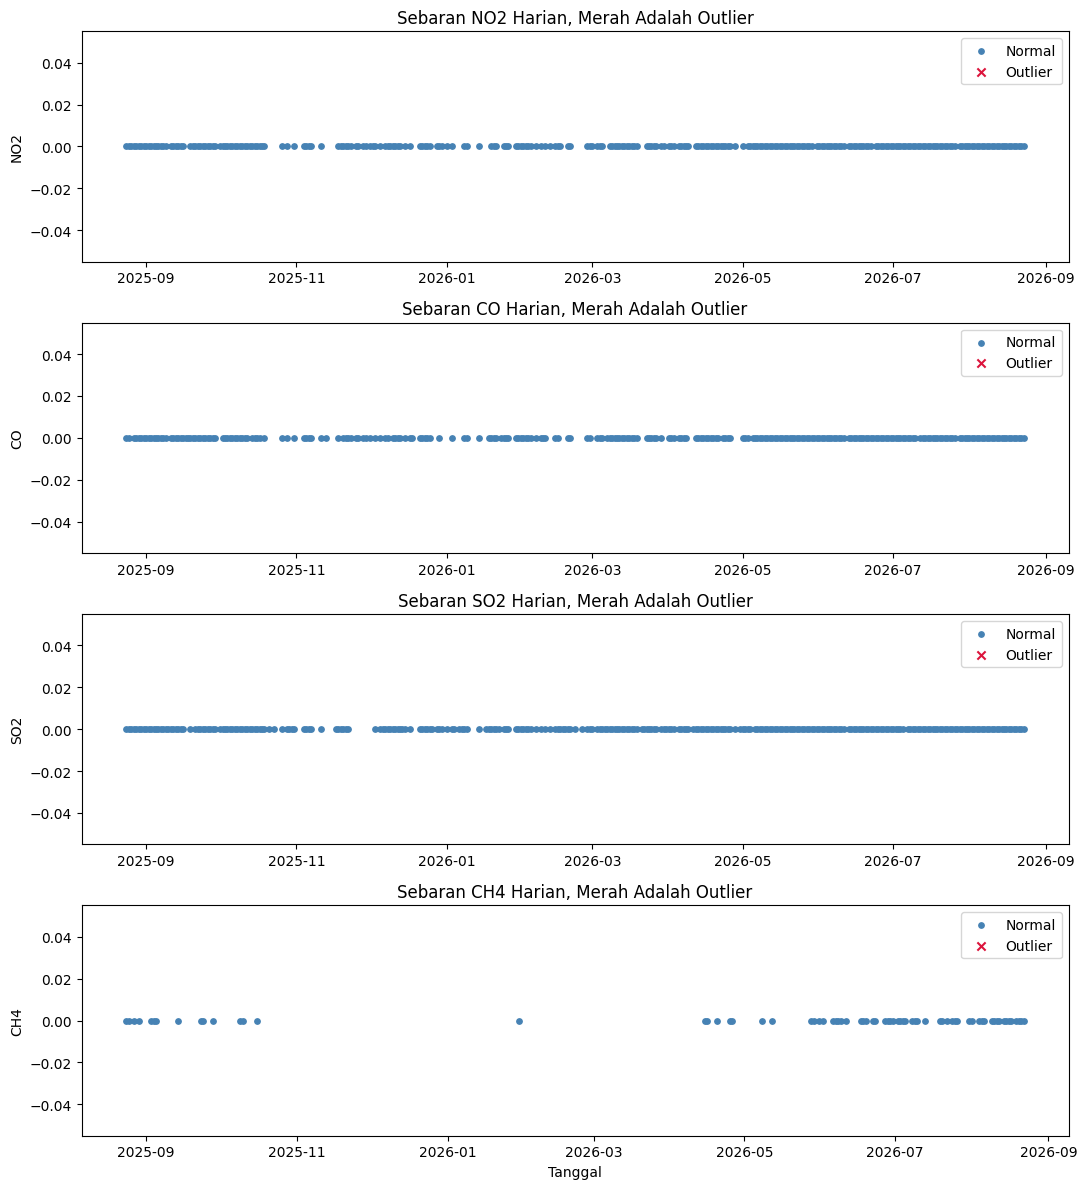

In [5]:
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

fig, axes = plt.subplots(len(pollutants), 1, figsize=(11, 3 * len(pollutants)), sharex=False)

for ax, pollutant in zip(axes, pollutants):
    df_clean = df.dropna(subset=[pollutant]).copy()

    model = IsolationForest(contamination=0.05, random_state=42)
    df_clean["outlier"] = model.fit_predict(df_clean[[pollutant]])

    normal = df_clean[df_clean["outlier"] == 1]
    outliers = df_clean[df_clean["outlier"] == -1]

    ax.scatter(normal["date"], normal[pollutant], color="steelblue", s=15, label="Normal")
    ax.scatter(outliers["date"], outliers[pollutant], color="crimson", s=35, marker="x", label="Outlier")
    ax.set_title(f"Sebaran {pollutant} Harian, Merah Adalah Outlier")
    ax.set_ylabel(pollutant)
    ax.legend(loc="upper right")

    print(f"{pollutant}: {len(outliers)} outlier dari {len(df_clean)} data valid")

axes[-1].set_xlabel("Tanggal")
plt.tight_layout()
plt.show()

## 6. Korelasi Antar Polutan

Sebagai eksplorasi tambahan, korelasi antar polutan dapat memberi
gambaran apakah polutan tertentu cenderung naik atau turun bersamaan,
yang dapat mengindikasikan sumber emisi yang berkaitan. Karena data
sudah berada dalam satu tabel gabungan, perhitungan korelasi tidak lagi
memerlukan penggabungan manual antar file.

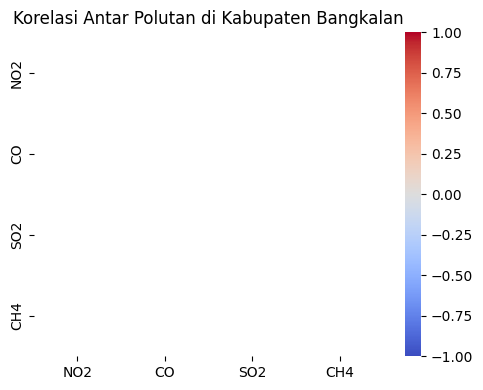

In [6]:
import seaborn as sns

corr = df[pollutants].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Korelasi Antar Polutan di Kabupaten Bangkalan")
plt.tight_layout()
plt.show()

## 7. Temuan Sementara

Beberapa hal yang perlu diperhatikan berdasarkan eksplorasi di atas, akan
terisi secara otomatis dengan angka sebenarnya begitu data hasil ekstraksi
tersedia.

1. Proporsi missing values pada tiap polutan, sebagai dasar penentuan
   metode penanganan yang tepat pada tahap berikutnya.
2. Jumlah dan sebaran waktu titik outlier pada tiap polutan, sebagai
   dasar penyelidikan lebih lanjut, apakah outlier tersebut mencerminkan
   kejadian nyata atau gangguan data.
3. Pola korelasi antar polutan, sebagai dasar dugaan awal mengenai
   keterkaitan sumber emisi, misalnya NO2 dan CO yang sama sama berasal
   dari transportasi.
4. Jika nilai pada statistik deskriptif (Bagian 3) menunjukkan seluruh
   angka bernilai nol, bukan angka kecil dalam notasi ilmiah, kemungkinan
   besar ada masalah pada tahap ekstraksi yang perlu ditelusuri kembali di
   notebook `4-ekstraksi-data.ipynb`, misalnya nama band yang salah atau
   nilai kosong yang tidak sengaja terisi nol.

## 8. Kesimpulan

Eksplorasi data menunjukkan bahwa data hasil ekstraksi Sentinel-5P untuk
Kabupaten Bangkalan sudah berada dalam struktur satu tabel gabungan yang
siap diolah, dengan rentang tanggal yang jelas untuk keempat polutan
sekaligus. Peta interaktif memastikan bahwa cakupan wilayah yang
diagregasi mengikuti bentuk administratif asli Kabupaten Bangkalan, bukan
kotak bounding box, termasuk titik titik dengan potensi sumber emisi
seperti akses Suramadu dan pesisir Klampis. Pemeriksaan missing values dan
deteksi outlier awal pada bagian ini menjadi dasar bagi penanganan data
yang lebih menyeluruh, seperti interpolasi nilai kosong dan investigasi
outlier, yang akan dilakukan pada notebook `5-analisis-bangkalan.ipynb`.